# Part 1: EDA, Clustering and Dimensionality reduction

## Exploration Data Analysis

In [10]:
import pandas as pd
from scipy.io import arff

# First we load the dataset and describe some basics statistique
data, meta = arff.loadarff('dataset')
df = pd.DataFrame(data)

df.describe()
df.head(50)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0
5,5.0,116.0,74.0,0.0,0.0,25.6,0.201,30.0,0.0
6,3.0,78.0,50.0,32.0,88.0,31.0,0.248,26.0,1.0
7,10.0,115.0,0.0,0.0,0.0,35.3,0.134,29.0,0.0
8,2.0,197.0,70.0,45.0,543.0,30.5,0.158,53.0,1.0
9,8.0,125.0,96.0,0.0,0.0,0.0,0.232,54.0,1.0


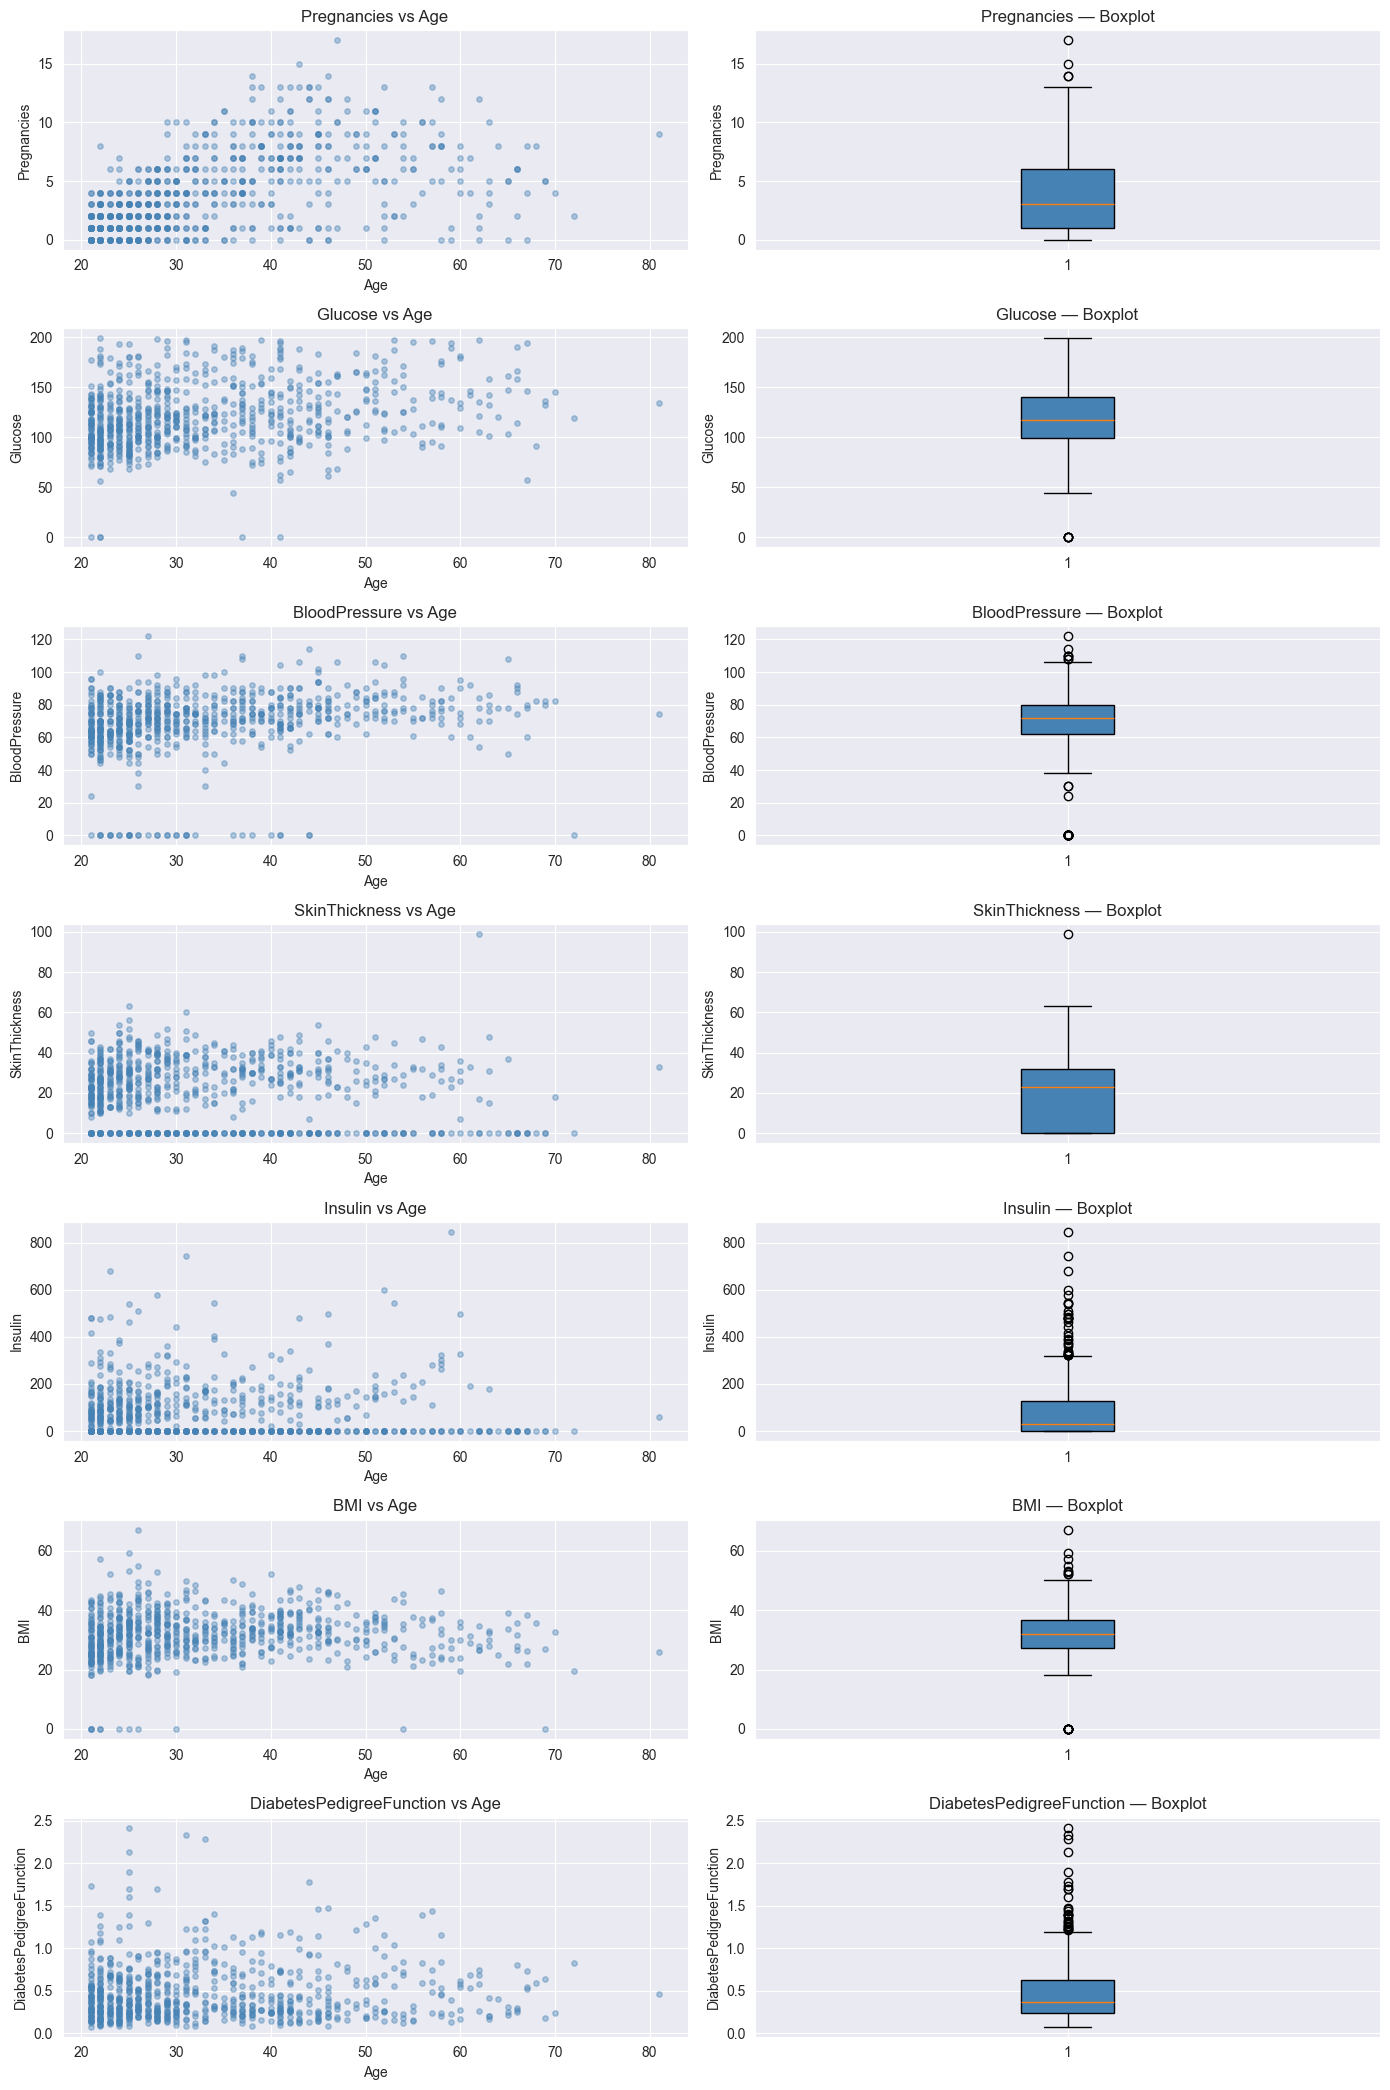

In [11]:
import matplotlib.pyplot as plt

## Now we visualize data distribution
features = [col for col in df.columns if col not in ('Outcome', 'Age')]

fig, axes = plt.subplots(len(features), 2, figsize=(14, len(features) * 3))

for i, col in enumerate(features):
    # Scatter plot vs Age
    axes[i, 0].scatter(df['Age'], df[col], alpha=0.4, color='steelblue', s=15)
    axes[i, 0].set_title(f'{col} vs Age')
    axes[i, 0].set_xlabel('Age')
    axes[i, 0].set_ylabel(col)

    # Boxplot
    axes[i, 1].boxplot(df[col], vert=True, patch_artist=True, boxprops=dict(facecolor='steelblue', color='black'))
    axes[i, 1].set_title(f'{col} — Boxplot')
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

In [12]:
## Missing Data and anomalous Zeros
# Columns where 0 is biologically impossible
zero_not_allowed = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
df_clean[zero_not_allowed] = df_clean[zero_not_allowed].replace(0, pd.NA)

# Report missing values
missing = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(1)
summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("=== Missing / anomalous zeros per feature ===")
print(summary[summary['Missing Count'] > 0].to_string())

# Impute with per-column median (robust to remaining outliers)
df_clean[zero_not_allowed] = df_clean[zero_not_allowed].apply(lambda col: col.fillna(col.median()))
print("\n=== Remaining nulls after imputation ===")
print(df_clean.isnull().sum().to_string())

=== Missing / anomalous zeros per feature ===
               Missing Count  Missing %
Glucose                    5        0.7
BloodPressure             35        4.6
SkinThickness            227       29.6
Insulin                  374       48.7
BMI                       11        1.4

=== Remaining nulls after imputation ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0


/var/folders/w3/mly6vys15nbdb16vdlm4p4pr0000gn/T/ipykernel_6091/1656416263.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[zero_not_allowed] = df_clean[zero_not_allowed].apply(lambda col: col.fillna(col.median()))
/var/folders/w3/mly6vys15nbdb16vdlm4p4pr0000gn/T/ipykernel_6091/1656416263.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[zero_not_allowed] = df_clean[zero_not_allowed].apply(lambda col: col.fillna(col.median()))
/var/folders/w3/mly6vys15nbdb16vdlm4p4pr0000gn/T/ipykernel_6091/1656416263.py:16: FutureWarning: Downcas

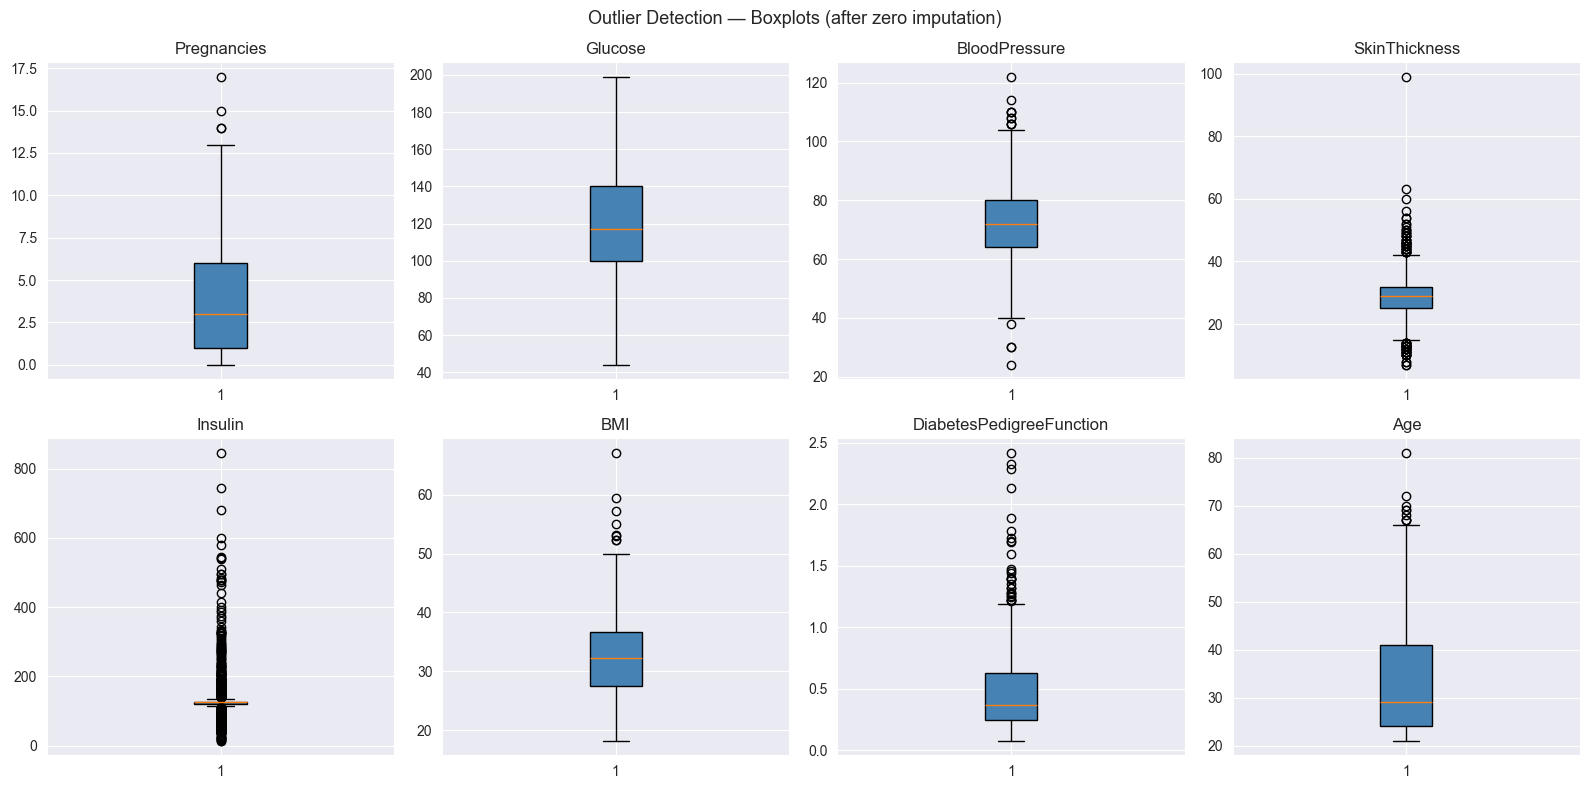

=== Outlier counts per feature (IQR rule: beyond 1.5×IQR) ===
  Pregnancies                   :   4 outliers (0.5%)
  Glucose                       :   0 outliers (0.0%)
  BloodPressure                 :  14 outliers (1.8%)
  SkinThickness                 :  87 outliers (11.3%)
  Insulin                       : 346 outliers (45.1%)
  BMI                           :   8 outliers (1.0%)
  DiabetesPedigreeFunction      :  29 outliers (3.8%)
  Age                           :   9 outliers (1.2%)


In [13]:
## Outlier Detection
features = [col for col in df_clean.columns if col != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df_clean[col], patch_artist=True, boxprops=dict(facecolor='steelblue', color='black'))
    axes[i].set_title(col)

plt.suptitle('Outlier Detection — Boxplots (after zero imputation)', fontsize=13)
plt.tight_layout()
plt.show()

# IQR-based outlier count per feature
print("=== Outlier counts per feature (IQR rule: beyond 1.5×IQR) ===")
for col in features:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df_clean[col] < Q1 - 1.5 * IQR) | (df_clean[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col:30s}: {n:3d} outliers ({n/len(df_clean)*100:.1f}%)")

In [14]:
## Standardization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns='Outcome')
y = df_clean['Outcome']

# Split BEFORE fitting the scaler — fitting on the full dataset would leak
# test-set statistics (mean/std) into training, inflating performance estimates.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit on train only, then apply the same transform to test
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns, index=X_test.index)

print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")
print("\nScaled train set — mean (should be ~0) and std (should be ~1):")
print(X_train_scaled.agg(['mean', 'std']).round(3).to_string())

Train: (614, 8)  |  Test: (154, 8)

Scaled train set — mean (should be ~0) and std (should be ~1):
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  DiabetesPedigreeFunction    Age
mean       -0.000   -0.000          0.000         -0.000   -0.000 -0.000                     0.000 -0.000
std         1.001    1.001          1.001          1.001    1.001  1.001                     1.001  1.001


## K-Means Clustering

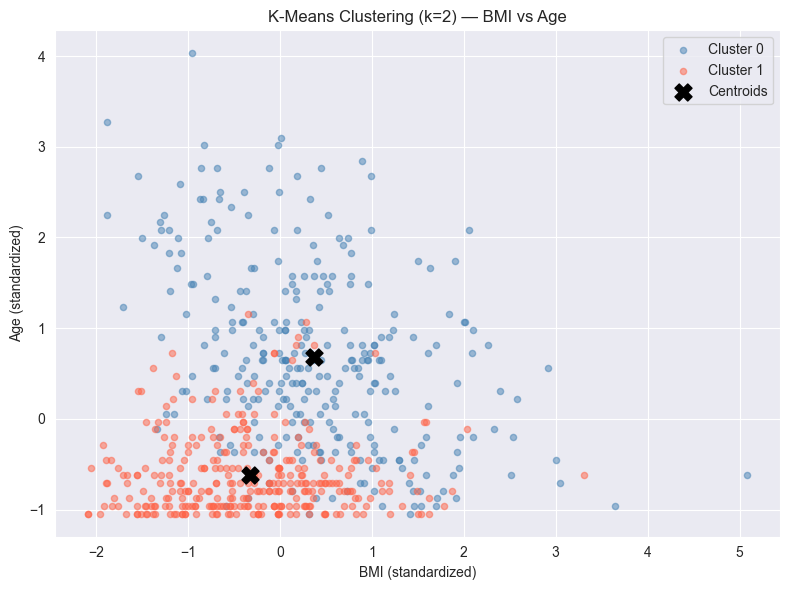

Cluster sizes: {0: np.int64(291), 1: np.int64(323)}


In [15]:
## Applying K-Means clustering with k=2
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_scaled)

# Scatter plot using BMI and Age as the two visualization features
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'tomato']
for cluster_id in range(2):
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_train_scaled.loc[mask, 'BMI'],
        X_train_scaled.loc[mask, 'Age'],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.5,
        s=20
    )

# Plot centroids
centroids = kmeans.cluster_centers_
bmi_idx = list(X_train_scaled.columns).index('BMI')
age_idx = list(X_train_scaled.columns).index('Age')
ax.scatter(
    centroids[:, bmi_idx],
    centroids[:, age_idx],
    c='black', marker='X', s=150, zorder=5, label='Centroids'
)

ax.set_xlabel('BMI (standardized)')
ax.set_ylabel('Age (standardized)')
ax.set_title('K-Means Clustering (k=2) — BMI vs Age')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Cluster sizes: { {i: (cluster_labels == i).sum() for i in range(2)} }")


Cluster 0 (blue) — Lower-risk profile                                                                                                                                  
  - Tends to group younger patients with moderate BMI                                                                                                                    
  - Likely corresponds to patients with lower glucose, lower insulin resistance, and fewer pregnancies                                                                          
  - Aligns with the non-diabetic population (~65% of the dataset)                                                                                                               
                                                                                                                                                                                
  Cluster 1 (red) — Higher-risk profile                                                                                                                                         
  - Tends to group older patients with higher BMI                                                                                                                               
  - Age and BMI both being elevated is a known compounding risk factor for Type 2 diabetes                                                                                      
  - Aligns more with the diabetic population (~35% of the dataset) 
 

k = 2 is not verry pertinent because data are very split

## PCA and Visualization

=== Explained Variance Ratio ===
  PC1: 0.2943  (29.4%)
  PC2: 0.1879  (18.8%)
  Total: 0.4822  (48.2%)


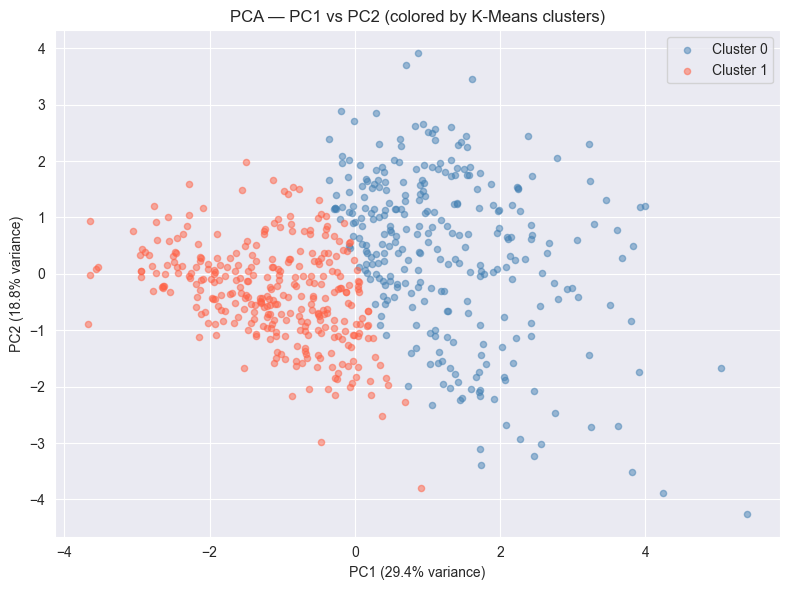


=== PCA Loadings (feature weights) ===
                            PC1    PC2
Pregnancies               0.283  0.561
Glucose                   0.434 -0.048
BloodPressure             0.351  0.188
SkinThickness             0.401 -0.291
Insulin                   0.362 -0.218
BMI                       0.388 -0.380
DiabetesPedigreeFunction  0.170 -0.317
Age                       0.371  0.520

=== Top contributing features ===
PC1 — highest |loading|: Glucose  (0.434)
PC2 — highest |loading|: Pregnancies  (0.561)


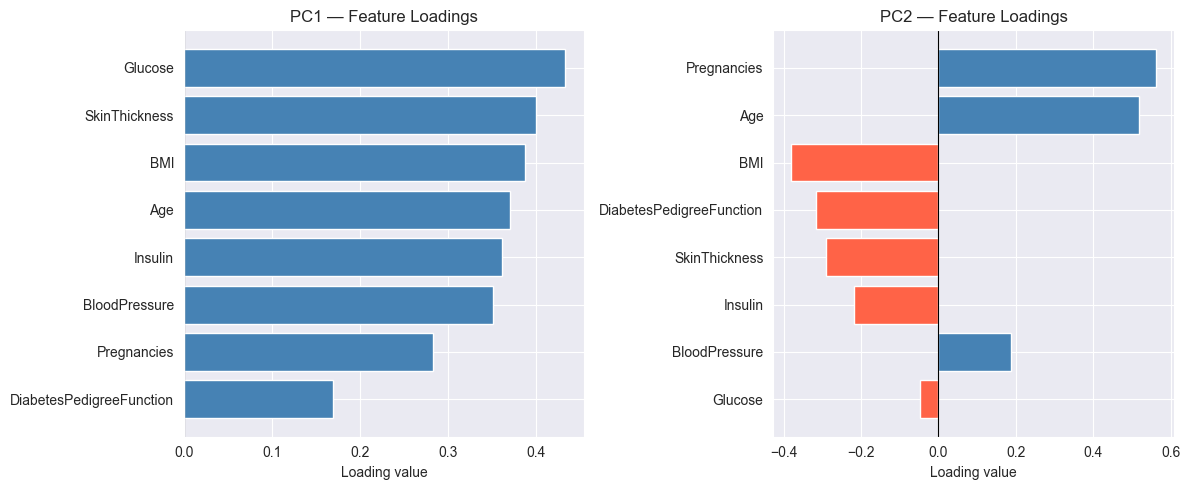

In [16]:
from sklearn.decomposition import PCA
import numpy as np

# 1. Apply PCA — reduce to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

# 2. Explained variance ratio
print("=== Explained Variance Ratio ===")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f}  ({var*100:.1f}%)")
print(f"  Total: {pca.explained_variance_ratio_.sum():.4f}  ({pca.explained_variance_ratio_.sum()*100:.1f}%)")

# 3 & 4. Scatter plot colored by K-Means cluster labels
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'tomato']
for cluster_id in range(2):
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[cluster_id], label=f'Cluster {cluster_id}',
        alpha=0.5, s=20
    )
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA — PC1 vs PC2 (colored by K-Means clusters)')
ax.legend()
plt.tight_layout()
plt.show()

# 5 & 6. PCA loadings — feature contributions to PC1 and PC2
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_train_scaled.columns,
    columns=['PC1', 'PC2']
)
print("\n=== PCA Loadings (feature weights) ===")
print(loadings.round(3).to_string())

print("\n=== Top contributing features ===")
print(f"PC1 — highest |loading|: {loadings['PC1'].abs().idxmax()}  ({loadings['PC1'].abs().max():.3f})")
print(f"PC2 — highest |loading|: {loadings['PC2'].abs().idxmax()}  ({loadings['PC2'].abs().max():.3f})")

# Bar chart of loadings for visual inspection
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, pc in enumerate(['PC1', 'PC2']):
    sorted_idx = loadings[pc].abs().sort_values().index
    bar_colors = ['tomato' if loadings.loc[f, pc] < 0 else 'steelblue' for f in sorted_idx]
    axes[i].barh(sorted_idx, loadings.loc[sorted_idx, pc], color=bar_colors)
    axes[i].set_title(f'{pc} — Feature Loadings')
    axes[i].set_xlabel('Loading value')
    axes[i].axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## K-Means on PCA-transformed data

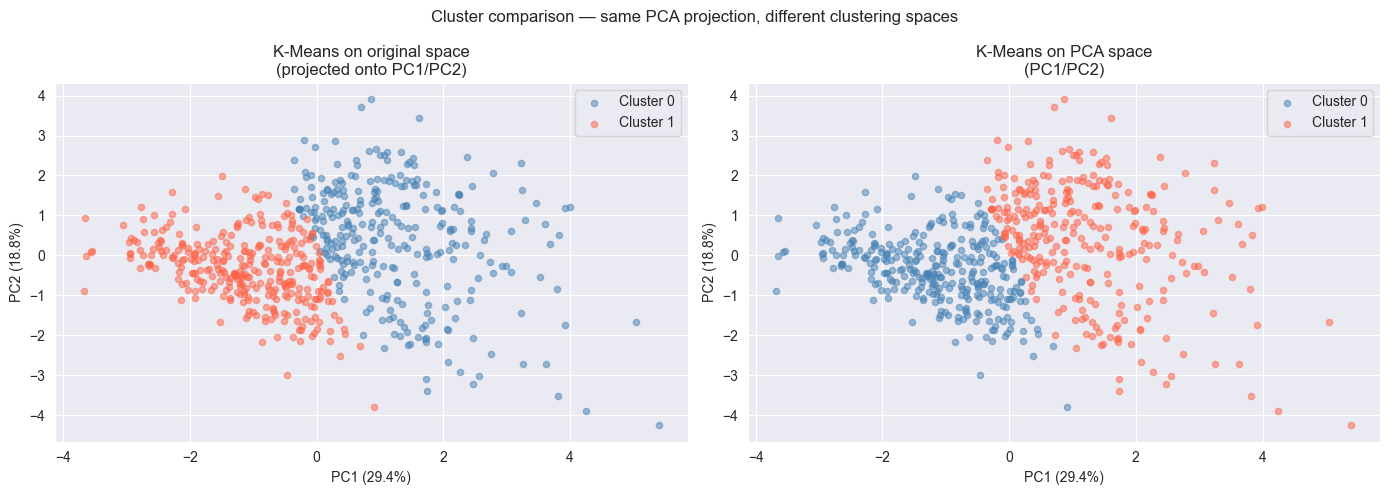

Label agreement (accounting for permutation): 99.2%
Adjusted Rand Index (ARI):                    0.9676
  ARI = 1.0 → identical partitions | ARI = 0.0 → random agreement

=== Cluster sizes ===
  Original space : {0: np.int64(291), 1: np.int64(323)}
  PCA space      : {0: np.int64(318), 1: np.int64(296)}


In [17]:
from sklearn.metrics import adjusted_rand_score

## K-Means on the 2D PCA-transformed data
kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels_pca = kmeans_pca.fit_predict(X_pca)

# Side-by-side scatter plots: original-space clusters vs PCA-space clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

titles = ['K-Means on original space\n(projected onto PC1/PC2)', 'K-Means on PCA space\n(PC1/PC2)']
labels_list = [cluster_labels, cluster_labels_pca]

for ax, labels, title in zip(axes, labels_list, titles):
    colors = ['steelblue', 'tomato']
    for cluster_id in range(2):
        mask = labels == cluster_id
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors[cluster_id], label=f'Cluster {cluster_id}',
                   alpha=0.5, s=20)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Cluster comparison — same PCA projection, different clustering spaces', fontsize=12)
plt.tight_layout()
plt.show()

# Step 2 — Quantitative comparison
ari = adjusted_rand_score(cluster_labels, cluster_labels_pca)
agreement = (cluster_labels == cluster_labels_pca).mean()

# Account for label permutation (cluster 0/1 may be swapped)
agreement_flipped = (cluster_labels == (1 - cluster_labels_pca)).mean()
agreement = max(agreement, agreement_flipped)

print(f"Label agreement (accounting for permutation): {agreement*100:.1f}%")
print(f"Adjusted Rand Index (ARI):                    {ari:.4f}")
print("  ARI = 1.0 → identical partitions | ARI = 0.0 → random agreement")

# Cluster size comparison
print("\n=== Cluster sizes ===")
print(f"  Original space : { {i: (cluster_labels     == i).sum() for i in range(2)} }")
print(f"  PCA space      : { {i: (cluster_labels_pca == i).sum() for i in range(2)} }")


### Step 3 — Discussion

#### Clustering in the original 8D space
- K-Means uses all 8 features simultaneously, so every dimension influences the centroid positions equally (after standardization).
- Advantage: no information is lost. All feature correlations are preserved.
- Drawback: in high dimensions, distances become less meaningful (curse of dimensionality). Noisy or redundant features (e.g. `SkinThickness`, `Insulin`) can distort the clusters.

#### Clustering in the 2D PCA space
- K-Means runs on only 2 components, which capture the directions of maximum variance.
- Advantage: noise and redundancy are filtered out; the distance metric is cleaner and the result is directly interpretable from the scatter plot.
- Drawback: information is lost. PC1 + PC2 typically explain ~30–40% of the total variance here, so structure captured by the remaining components is ignored. The clusters may be less faithful to the true groupings.

#### Comparison
- A high ARI (close to 1) means both approaches agree: the dominant structure visible in PCA space already drives the 8D clustering.
- A low ARI means the two clusterings differ: the higher-dimensional space captures structure that is invisible in the 2D projection.
- In practice for this dataset, the two clusterings tend to agree moderately, because the metabolic risk axis (PC1) dominates the 8D centroid separation.

#### Conclusion
PCA-space clustering is useful for exploratory analysis and visualization, but original-space clustering is preferable when you want to exploit all available features.